In [1]:
import pandas as pd
import sys
import numpy as np

In [2]:
# make a list of file in the directory

import os

folder_of_interest_list = [
    'results_GP_shipsnet_newslate_guide_SEU',
    'results_shipsnet_01_SEU',
    'results_shipsnet_02_SEU',
    'results_shipsnet_03_SEU',
    ]

df_master = pd.read_csv(r'results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234102.csv')
# delete all rows leaving the columns only
# add a column called folder_name
df_master['folder_name'] = ""
df_master = df_master.drop(df_master.index)

for foil in folder_of_interest_list:

#folder_of_interest = 'results_shipsnet_01_SEU'
#folder_of_interest = 'results_GP_shipsnet_newslate_guide_SEU'

#df_master = pd.read_csv(r'results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234102.csv')
# add a column called timestamp, which is the filename without the extension
#df_master['timestamp'] = ""

    search_dir = os.path.join('results_4_variants',
                            foil,
    )

    for file in os.listdir(search_dir):
        if file.endswith('.csv'):
            file_path = os.path.join(search_dir, file)
            print(f"Processing file: {file_path}")
            df = pd.read_csv(file_path)
            df['folder_name'] = foil
            # remove if accuracy_after_seu is nan
            df = df[df['accuracy_after_seu'].notna()]
            print(f"Number of rows after removing NaN in 'accuracy_after_seu': {len(df)}")
            #remove duplicate rows based on the first 10 columns
            print(f"Number of rows before dropping duplicates: {len(df)}")
            df = df.drop_duplicates(subset=df.columns[:10])
            print(f"Number of rows after dropping duplicates: {len(df)}")
            # append the data to the master dataframe
            df_master = pd.concat([df_master, df], ignore_index=True)
    #

# filter accuracy_change to only non nan values
#abs_acc_change_mean = df_master[df_master['accuracy_change'].notna()]['accuracy_change'].abs().mean()
#abs_acc_change_mean\
df_master['abs_acc_diff'] = df_master['accuracy_change'].abs()
df_master['log_mean_abs_difference'] = df_master['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else np.nan)

Processing file: results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234102.csv
Number of rows after removing NaN in 'accuracy_after_seu': 624
Number of rows before dropping duplicates: 624
Number of rows after dropping duplicates: 156
Processing file: results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234248.csv
Number of rows after removing NaN in 'accuracy_after_seu': 624
Number of rows before dropping duplicates: 624
Number of rows after dropping duplicates: 156
Processing file: results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234253.csv
Number of rows after removing NaN in 'accuracy_after_seu': 552
Number of rows before dropping duplicates: 552
Number of rows after dropping duplicates: 144
Processing file: results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250719_004433.csv
Number of rows after removing NaN in 'accuracy_after_seu': 552
Number of rows before dropping duplicates: 552
Number of rows after dropping duplicat

In [3]:
df_master

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,folder_name,abs_acc_diff,log_mean_abs_difference
0,relu,gaussian,0.874062,0.0,1.0,locs,0,conv1,weight,0,0.91375,0.91250,-0.00125,0.294718,2.305325e-02,results_GP_shipsnet_newslate_guide_SEU,0.00125,-1.637268
1,relu,gaussian,0.874062,0.0,1.0,locs,0,conv1,weight,1,0.91375,0.71375,-0.20000,0.892419,3.922308e+36,results_GP_shipsnet_newslate_guide_SEU,0.20000,36.593542
2,relu,gaussian,0.874062,0.0,1.0,scales,0,conv1,weight,1,0.91375,0.75000,-0.16375,1.000000,1.020613e+38,results_GP_shipsnet_newslate_guide_SEU,0.16375,38.008861
3,relu,gaussian,0.874062,0.0,1.0,locs,0,conv1,weight,3,0.91375,0.91375,0.00000,0.295114,1.152663e-02,results_GP_shipsnet_newslate_guide_SEU,0.00000,-1.938298
4,relu,gaussian,0.874062,0.0,1.0,scales,0,conv1,weight,3,0.91375,0.90625,-0.00750,0.291840,2.999313e-01,results_GP_shipsnet_newslate_guide_SEU,0.00750,-0.522978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12750,actRWG,gaussian,0.850625,0.0,1.0,scales,-1,fc1,bias,10,0.89125,0.89125,0.00000,0.203393,7.812500e-03,results_shipsnet_03_SEU,0.00000,-2.107210
12751,actRWG,gaussian,0.850625,0.0,1.0,locs,-1,fc1,bias,15,0.89125,0.89750,0.00625,0.200889,6.103516e-05,results_shipsnet_03_SEU,0.00625,-4.214420
12752,actRWG,gaussian,0.850625,0.0,1.0,scales,-1,fc1,bias,15,0.89125,0.88875,-0.00250,0.200198,2.441406e-04,results_shipsnet_03_SEU,0.00250,-3.612360
12753,actRWG,gaussian,0.850625,0.0,1.0,locs,-1,fc1,bias,21,0.89125,0.88875,-0.00250,0.202431,9.536743e-07,results_shipsnet_03_SEU,0.00250,-6.020600


In [4]:
df_master["bit_index"].unique()

array([ 0,  1,  3,  6, 10, 15, 21])

In [5]:
df_master[(df_master['bit_index'] == 1) & (df_master['prior'] == 'uniform')]

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,folder_name,abs_acc_diff,log_mean_abs_difference
313,relu,uniform,0.906875,0.0,1.0,widths,0,conv1,weight,1,0.89500,0.88625,-0.00875,0.204390,4.109301e+37,results_GP_shipsnet_newslate_guide_SEU,0.00875,37.613768
324,relu,uniform,0.906875,0.0,1.0,widths,0,conv1,bias,1,0.89500,0.88000,-0.01500,0.234087,4.107555e+37,results_GP_shipsnet_newslate_guide_SEU,0.01500,37.613583
335,relu,uniform,0.906875,0.0,1.0,widths,0,conv2,weight,1,0.89500,0.90125,0.00625,0.209239,4.110629e+37,results_GP_shipsnet_newslate_guide_SEU,0.00625,37.613908
346,relu,uniform,0.906875,0.0,1.0,widths,0,conv2,bias,1,0.89500,0.90625,0.01125,0.209685,4.110513e+37,results_GP_shipsnet_newslate_guide_SEU,0.01125,37.613896
357,relu,uniform,0.906875,0.0,1.0,widths,0,fc1,weight,1,0.89500,0.91500,0.02000,0.209665,4.110699e+37,results_GP_shipsnet_newslate_guide_SEU,0.02000,37.613916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12438,actRWG,uniform,0.899062,0.0,1.0,lows,-1,conv1,bias,1,0.89875,0.89625,-0.00250,0.206192,2.328724e+37,results_shipsnet_03_SEU,0.00250,37.367118
12439,actRWG,uniform,0.899062,0.0,1.0,lows,-1,conv2,weight,1,0.89875,0.90125,0.00250,0.204833,1.796388e+37,results_shipsnet_03_SEU,0.00250,37.254400
12440,actRWG,uniform,0.899062,0.0,1.0,lows,-1,conv2,bias,1,0.89875,0.89500,-0.00375,0.204891,2.086299e+37,results_shipsnet_03_SEU,0.00375,37.319377
12441,actRWG,uniform,0.899062,0.0,1.0,lows,-1,fc1,weight,1,0.89875,0.89500,-0.00375,0.203449,2.162632e+37,results_shipsnet_03_SEU,0.00375,37.334983


In [6]:
df_summary = df_master.groupby(['activation_fn',
                   'prior',
                   'param_type',
                   'location_index',
                   'location_layer',
                   'location_module',
                   'folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary

,activation_fn,prior,param_type,location_index,location_layer,location_module,folder_name,abs_acc_diff,softmax_difference
0,actRWG,gaussian,locs,-1,conv1,bias,results_GP_shipsnet_newslate_guide_SEU,0.002679,0.208321
1,actRWG,gaussian,locs,-1,conv1,bias,results_shipsnet_01_SEU,0.002679,0.213050
2,actRWG,gaussian,locs,-1,conv1,bias,results_shipsnet_02_SEU,0.006786,0.211636
3,actRWG,gaussian,locs,-1,conv1,bias,results_shipsnet_03_SEU,0.002857,0.202096
4,actRWG,gaussian,locs,-1,conv1,weight,results_GP_shipsnet_newslate_guide_SEU,0.005179,0.208520
...,...,...,...,...,...,...,...,...,...
2011,tanh,uniform,widths,0,fc1,bias,results_shipsnet_03_SEU,0.006500,0.219363
2012,tanh,uniform,widths,0,fc1,weight,results_GP_shipsnet_newslate_guide_SEU,0.004500,0.217462
2013,tanh,uniform,widths,0,fc1,weight,results_shipsnet_01_SEU,0.002250,0.219485
2014,tanh,uniform,widths,0,fc1,weight,results_shipsnet_02_SEU,0.009000,0.214499


In [7]:
df_master.sort_values(by='abs_acc_diff', ascending=False)

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,folder_name,abs_acc_diff,log_mean_abs_difference
4904,sin,gaussian,0.843750,0.0,1.0,locs,0,fc1,weight,1,0.93375,0.25250,-0.68125,0.609799,2.566158e+36,results_shipsnet_01_SEU,0.68125,36.409283
6442,relu,gaussian,0.887813,0.0,1.0,locs,0,fc1,bias,1,0.92125,0.25000,-0.67125,0.618064,6.983809e+35,results_shipsnet_02_SEU,0.67125,35.844092
3542,relu,gaussian,0.864062,0.0,1.0,locs,0,fc1,weight,1,0.92125,0.25000,-0.67125,0.616078,2.907174e+37,results_shipsnet_01_SEU,0.67125,37.463471
11205,sin,gaussian,0.839063,0.0,1.0,locs,-1,fc1,weight,1,0.92125,0.25250,-0.66875,0.607684,1.209880e+36,results_shipsnet_03_SEU,0.66875,36.082742
3619,relu,gaussian,0.864062,0.0,1.0,scales,-1,fc1,weight,1,0.92125,0.25250,-0.66875,0.989759,3.295976e+38,results_shipsnet_01_SEU,0.66875,38.517984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12667,actRWG,gaussian,0.850625,0.0,1.0,locs,0,fc1,bias,3,0.89125,0.89125,0.00000,0.201642,1.332841e-02,results_shipsnet_03_SEU,0.00000,-1.875222
6643,relu,uniform,0.908438,0.0,1.0,lows,-1,fc1,weight,3,0.90875,0.90875,0.00000,0.219829,6.257465e-02,results_shipsnet_02_SEU,0.00000,-1.203602
7867,sin,uniform,0.882188,0.0,1.0,widths,-1,fc1,bias,15,0.89500,0.89500,0.00000,0.214735,4.882812e-04,results_shipsnet_02_SEU,0.00000,-3.311330
7880,sin,uniform,0.882188,0.0,1.0,lows,-1,fc1,weight,1,0.89750,0.89750,0.00000,0.214689,2.277429e+37,results_shipsnet_02_SEU,0.00000,37.357445


In [ ]:
#df_master[df_master['bit_index']==1].to_csv("index_1_check.csv", index=False)

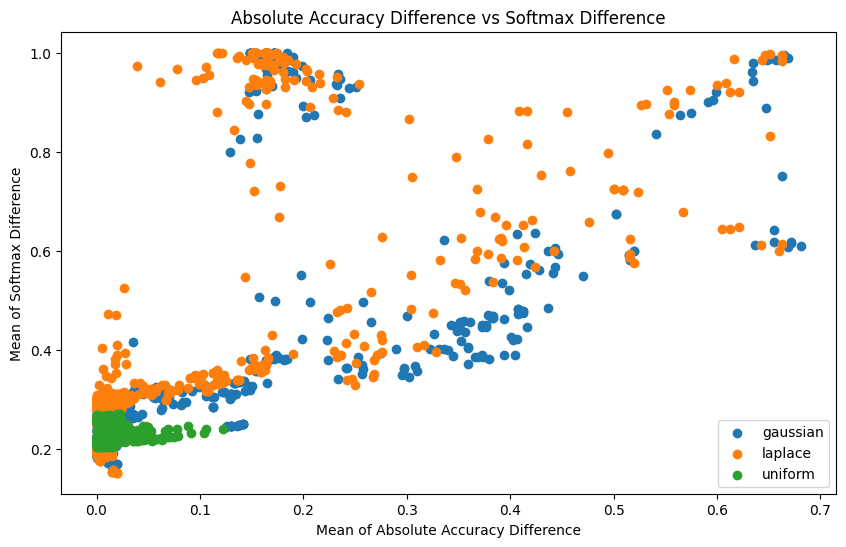

In [8]:
# make a scatter plot of abs_acc_diff vs softmax_difference
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for prior in df_master['prior'].unique():
    subset = df_master[df_master['prior'] == prior]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=prior)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()
plt.show()

In [ ]:
# make a scatter plot of abs_acc_diff vs softmax_difference
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for folder in df_summary['folder_name'].unique():
    subset = df_summary[df_summary['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()
plt.show()

In [ ]:
df_summary_2 = df_master.groupby(['location_layer',
                                  'location_module'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_2

In [ ]:
# make a scatter plot of abs_acc_diff vs softmax_difference
# create different shape by location_layer and location_module
plt.figure(figsize=(10, 6))
for layer in df_summary_2['location_layer'].unique():
    for module in df_summary_2['location_module'].unique():
        subset = df_summary_2[(df_summary_2['location_layer'] == layer) & (df_summary_2['location_module'] == module)]
        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{layer} - {module}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer and Module')
plt.legend()

In [ ]:
df_summary_3 = df_master.groupby(['activation_fn'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_3

In [ ]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))
for activation in df_summary_3['activation_fn'].unique():
    subset = df_summary_3[df_summary_3['activation_fn'] == activation]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=activation)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Activation Function')
plt.legend()

In [ ]:
df_summary_4 = df_master.groupby(['prior'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_4

In [ ]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))
for prior in df_summary_4['prior'].unique():
    subset = df_summary_4[df_summary_4['prior'] == prior]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=prior)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Prior')
plt.legend()
plt.show()

In [ ]:
df_summary_5 = df_master.groupby(['prior','param_type'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_5

In [ ]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))

# make a custom cumbination of prior and param_type
param_dict = {
    'gaussian': ['locs','scales'],
    'uniform': ['lows','widths'],
    'laplace': ['locs','scales'],}

# giva a very contrast different color other that seaborn-darkgrid
import matplotlib.pyplot as plt
#plt.style.use('seaborn-darkgrid')

for prior in param_dict.keys():
    for param_type in param_dict[prior]:
        subset = df_summary_5[(df_summary_5['prior'] == prior) & (df_summary_5['param_type'] == param_type)]
        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{prior} - {param_type}')


plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Prior and Parameter Type')
plt.legend()
plt.show()

In [ ]:
df_summary_6 = df_master.groupby(['folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_6

In [ ]:
# make a scatter plot of abs_acc_diff vs softmax_difference from df_summary_6
plt.figure(figsize=(10, 6))
for folder in df_summary_6['folder_name'].unique():
    subset = df_summary_6[df_summary_6['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Folder')
plt.legend()
plt.show()


In [ ]:
df_summary_7 = df_master.groupby(['location_index','location_layer', 'location_module'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_7

In [ ]:
plt.figure(figsize=(10, 6))
for layer in df_summary_7['location_layer'].unique():
    for module in df_summary_7['location_module'].unique():
        for location_index in df_summary_7['location_index'].unique():
            subset = df_summary_7[(df_summary_7['location_layer'] == layer) & (df_summary_7['location_module'] == module) & (df_summary_7['location_index'] == location_index)]
            plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'],label=f'{layer} - {module} - {location_index}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer, Module, Location Index')
plt.legend()
plt.show()

In [ ]:
# filter df to only show those with prior_b = 1
prior_b_filter = 1.0
activation_fn_filter = 'actWG'
prior_filter = 'gaussian'
param_type_filter = 'locs'


df_target = df_master[(df_master['prior_b'] == prior_b_filter) & 
                      (df_master['activation_fn'] == activation_fn_filter) &
                      #(df_master['bit_index'] == 1) &
                      (df_master['prior'] == prior_filter) &
                      (df_master['param_type'] == param_type_filter)].reset_index(drop=True)

#mean_acc_diff = df_target['abs_acc_diff'].mean()

#df_target = df_target[df_target['activation_fn'] == 'relu'].reset_index(drop=True)
#df_target = df_target[df_target['bit_index'] == 1].reset_index(drop=True)
#df_target = df_target[df_target['prior'] == 'gaussian'].reset_index(drop=True)
df_target

In [ ]:
# plot the result
# x axis is the absoulte value of the difference of accuracy
# y axis is the log of the mean_abs_difference
import matplotlib.pyplot as plt
import numpy as np

df_target['abs_acc_diff'] = df_target['accuracy_change'].abs()
df_target['log_mean_abs_difference'] = df_target['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else pd.np.nan)

abs_acc_change_mean = df_target[df_target['accuracy_change'].notna()]['accuracy_change'].abs().mean()

#color by the bit_index
df_target['bit_index'] = df_target['bit_index'].astype(str)

plt.figure(figsize=(10, 6))
#plt.scatter(df_target['abs_acc_diff'], df_target['log_mean_abs_difference'], alpha=0.5)
# add folder_of_interest, prior_b, activation_fn, prior, param_type to the title
plt.title(f'Absolute Mean in Accuracy vs Log Mean Absolute Difference\nShipsNet SEU Analysis: {folder_of_interest} | Prior b: {prior_b_filter} | \nActivation Function: {activation_fn_filter} | Prior: {prior_filter} | Param Type: {param_type_filter}\n Mean Accuracy Difference: {abs_acc_change_mean:.4f}')
#plt.title('Absolute Mean in Accuracy vs Log Mean Absolute Difference')
plt.xlabel('Absolute Difference of Accuracy')
plt.ylabel('Log Mean Absolute Difference')
#plt.yscale('log')

# create a dictionary to map bit_index to colors
colors = {'0': 'blue', 
          '1': 'orange', 
          '3': 'green', 
          '6': 'red', 
          '10': 'purple', 
          '15': 'brown', 
          '21': 'pink', 
          '30': 'gray'}

plt.scatter(df_target['abs_acc_diff'], 
            df_target['log_mean_abs_difference'],
            c=df_target['bit_index'].map(colors),
            alpha=0.5, label=df_target['bit_index'])

#show legend
#plt.colorbar(label='Bit Index')
plt.grid(True)
plt.show()

In [ ]:
stopdeh

In [ ]:
df_target

In [ ]:
df_target = df_master[(df_master['prior_b'] == 1.0) & 
                      (df_master['activation_fn'] == 'relu') &
                      #(df_master['bit_index'] == 1) &
                      (df_master['prior'] == 'gaussian') &
                      (df_master['param_type'] == 'scales')].reset_index(drop=True)

#df_target = df_target[df_target['activation_fn'] == 'relu'].reset_index(drop=True)
#df_target = df_target[df_target['bit_index'] == 1].reset_index(drop=True)
#df_target = df_target[df_target['prior'] == 'gaussian'].reset_index(drop=True)
df_target

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_target['abs_acc_diff'] = df_target['accuracy_change'].abs()
df_target['log_mean_abs_difference'] = df_target['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else pd.np.nan)

#color by the bit_index
df_target['bit_index'] = df_target['bit_index'].astype(str)

plt.figure(figsize=(10, 6))
#plt.scatter(df_target['abs_acc_diff'], df_target['log_mean_abs_difference'], alpha=0.5)
plt.title('Softmax Difference vs Log Mean Absolute Difference')
plt.xlabel('Absolute Difference of Accuracy')
plt.ylabel('Log Mean Absolute Difference')
#plt.yscale('log')

# create a dictionary to map bit_index to colors
colors = {'0': 'blue', 
          '1': 'orange', 
          '3': 'green', 
          '6': 'red', 
          '10': 'purple', 
          '15': 'brown', 
          '21': 'pink', 
          '30': 'gray'}

plt.scatter(df_target['abs_acc_diff'], 
            df_target['log_mean_abs_difference'],
            c=df_target['bit_index'].map(colors),
            alpha=0.5, label=df_target['bit_index'])

#show legend
#plt.colorbar(label='Bit Index')
plt.grid(True)
plt.show()

In [ ]:
def plot_seu_result():
    """
    input : what variables to show, what parameters to filter
    output : show graph
    """

    # plot the graph

    pass